{'run_type': 'test', 'run_note': 'Preparing for 2025 model with 2024 data and updated sales', 'toggle': {'cv_enable': True, 'shap_enable': True, 'comp_enable': True, 'upload_enable': True}, 'assessment': {'year': '2025', 'date': '2025-01-01', 'triad': 'north', 'group': 'residential', 'data_year': '2024', 'working_year': '2025'}, 'input': {'min_sale_year': '2016', 'max_sale_year': '2024', 'n_years_prior': 4, 'complex': {'match_exact': ['meta_township_code', 'meta_class', 'char_bsmt', 'char_gar1_size', 'char_attic_fnsh', 'char_beds', 'meta_pin_num_cards', 'meta_tieback_proration_rate'], 'match_fuzzy': {'rooms': 1, 'bldg_sf': 25, 'yrblt': 4, 'dist_ft': 250}}}, 'cv': {'split_prop': 0.9, 'num_folds': 10, 'fold_overlap': 9, 'initial_set': 20, 'max_iterations': 2000, 'no_improve': 15, 'uncertain': 8, 'best_metric': 'rmse'}, 'model': {'engine': 'lightgbm', 'objective': 'rmse', 'seed': 2025, 'deterministic': True, 'force_row_wise': True, 'verbose': -1, 'predictor': {'all': ['meta_township_code'

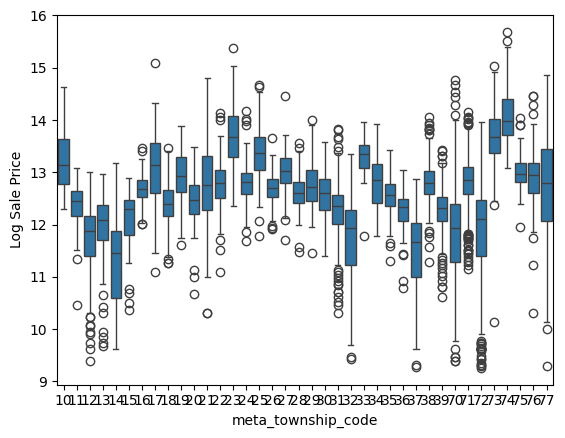

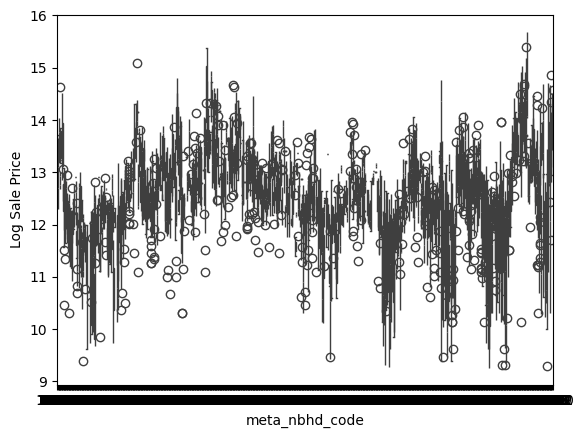

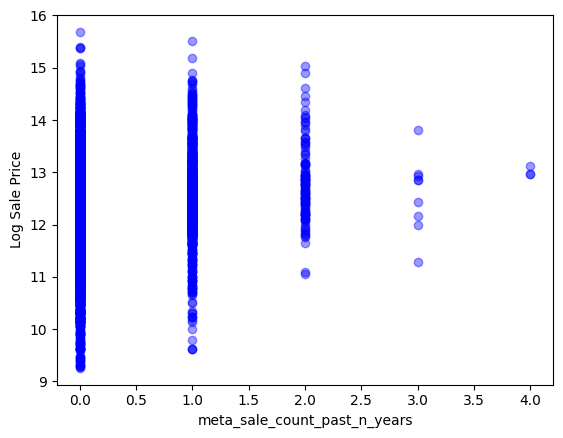

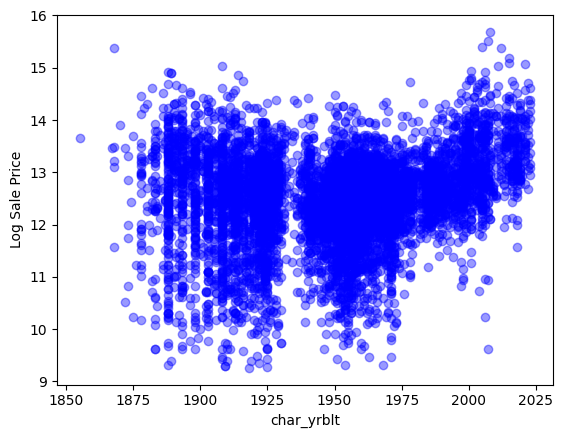

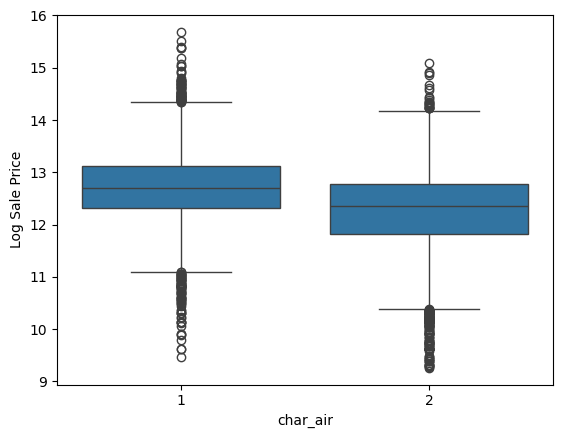

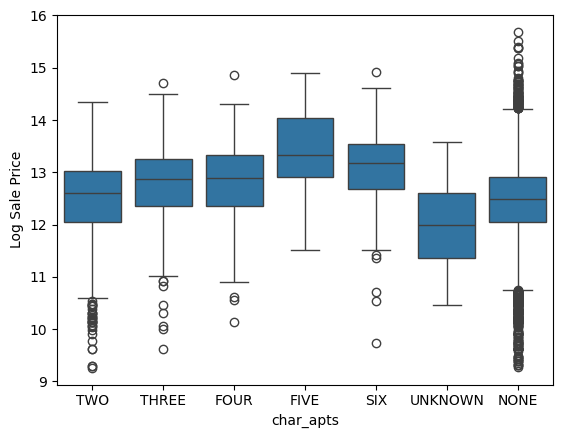

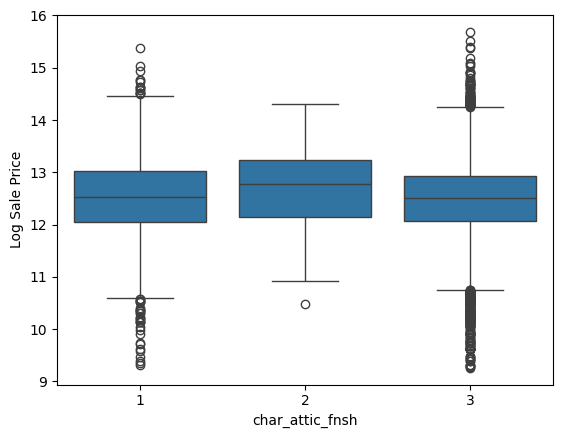

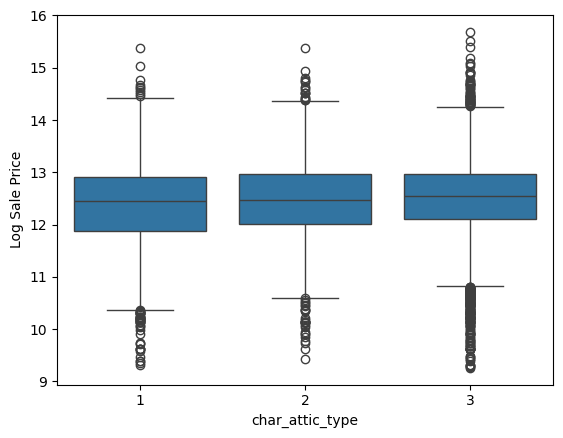

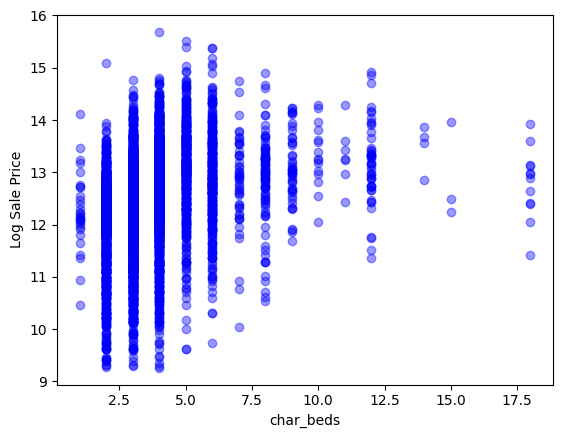

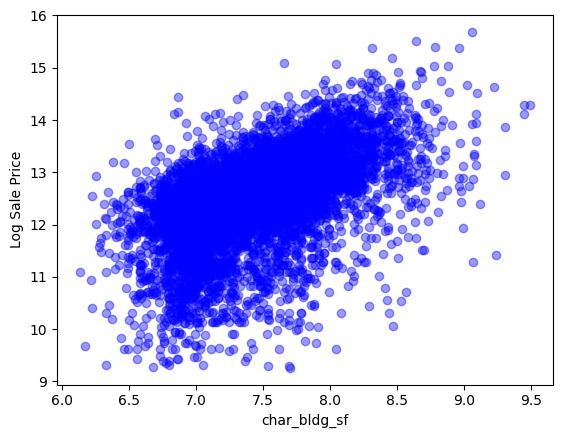

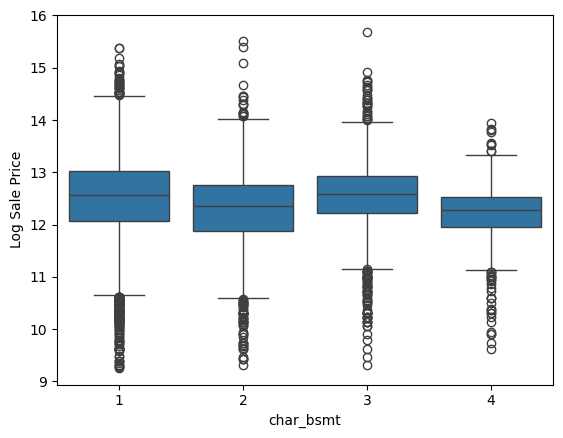

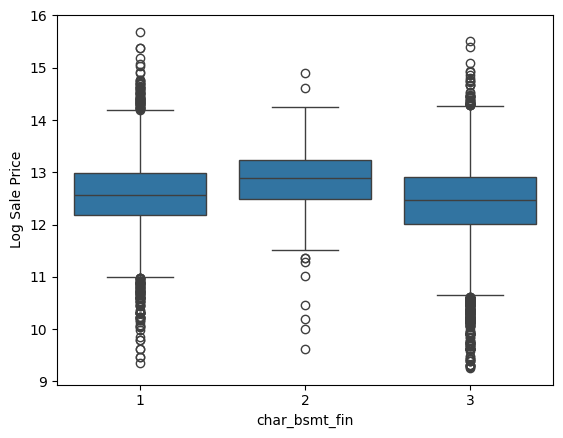

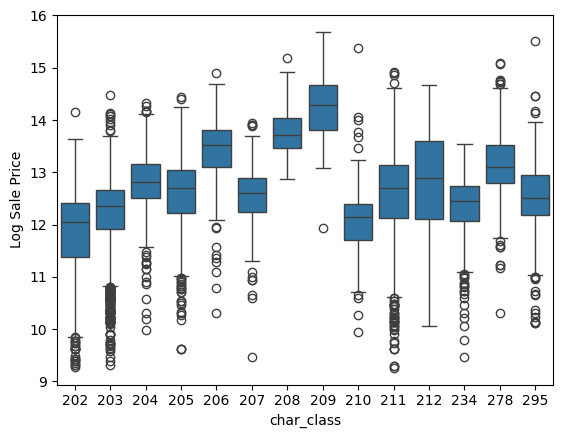

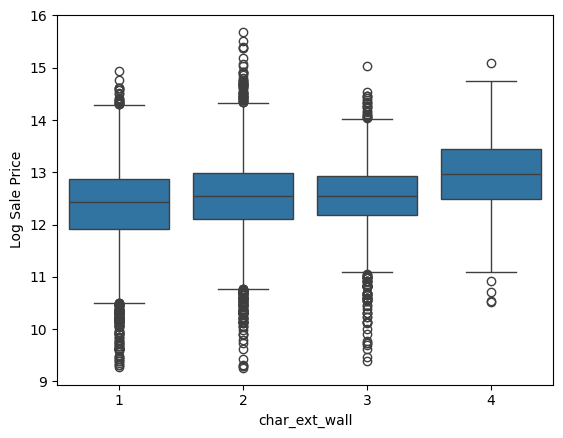

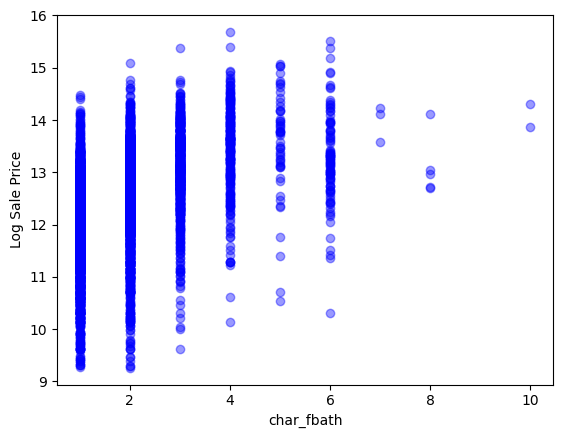

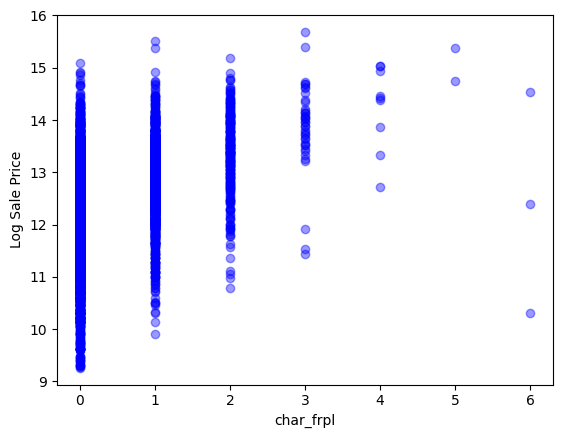

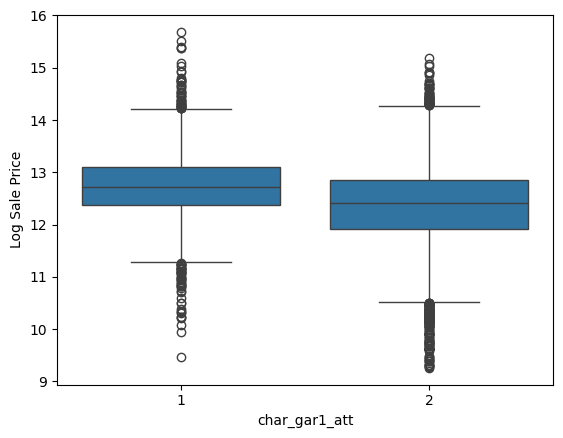

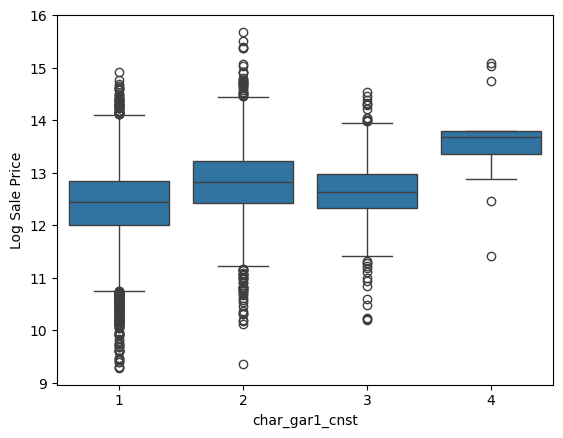

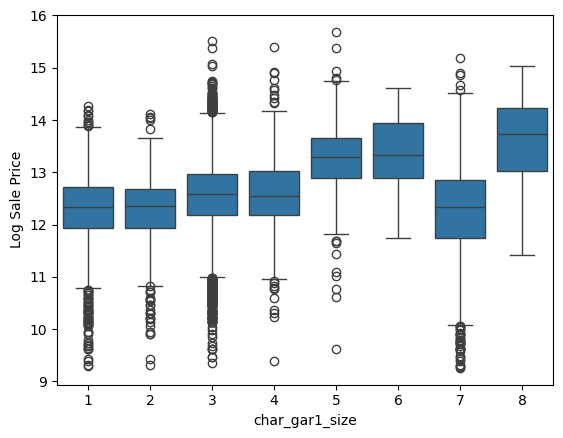

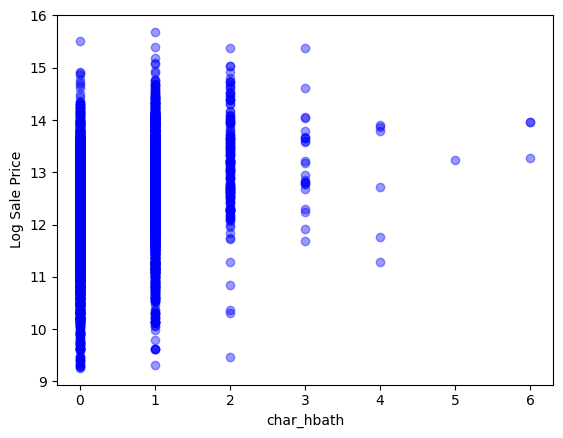

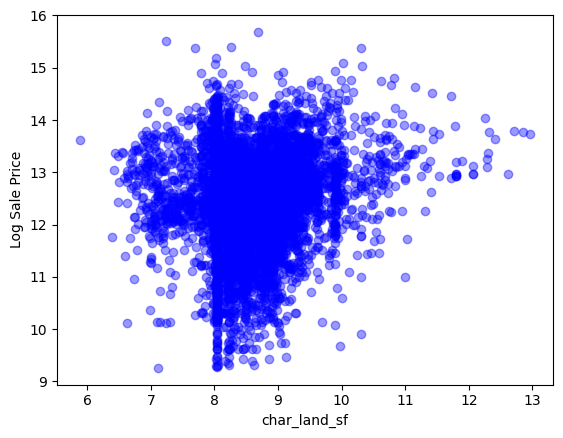

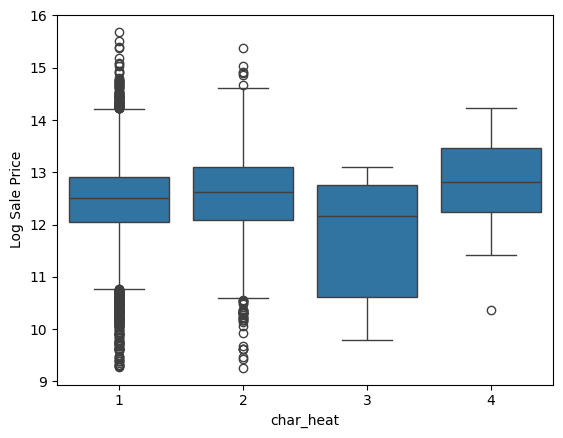

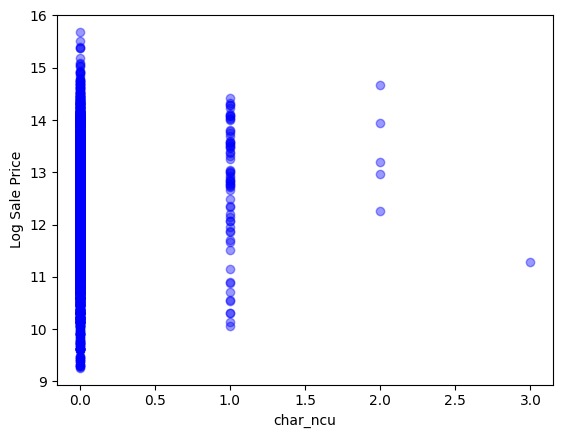

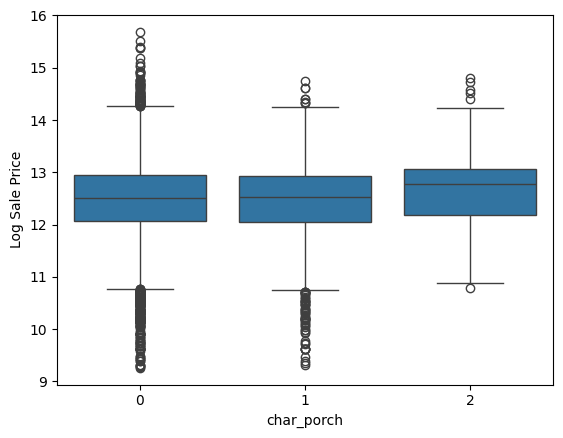

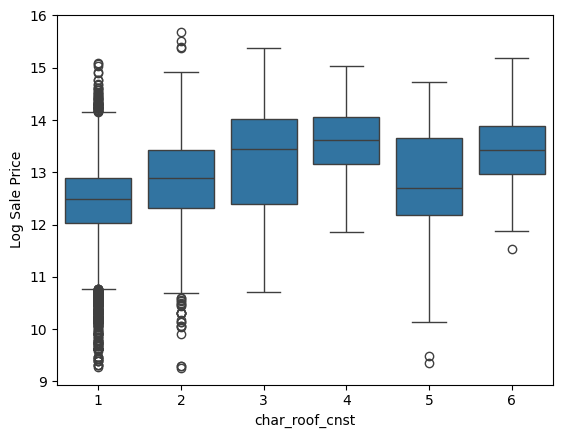

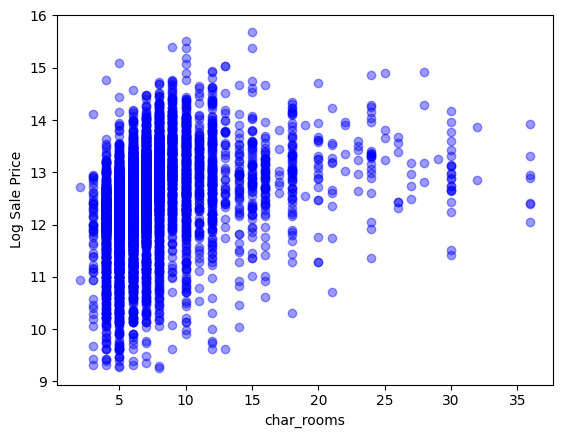

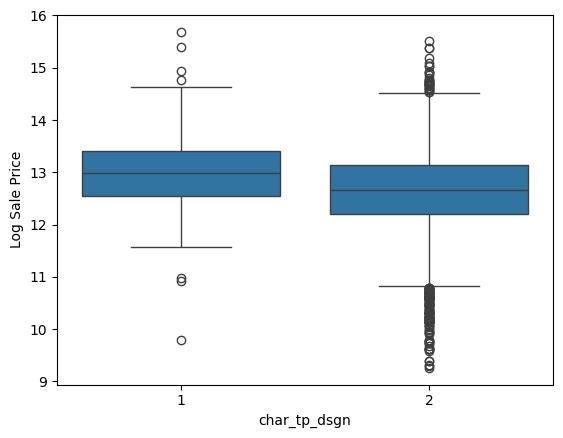

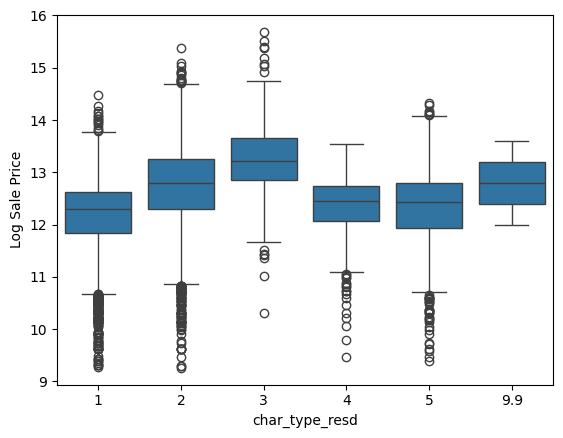

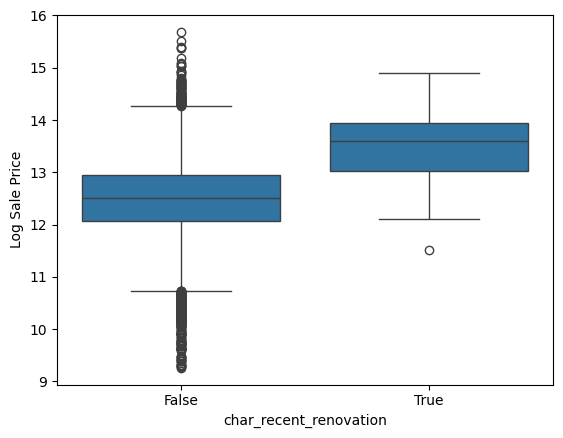

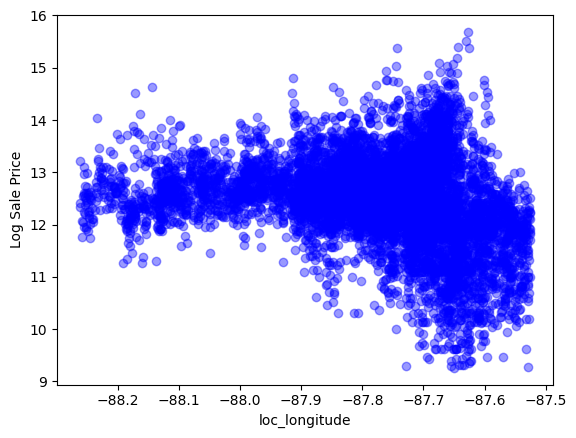

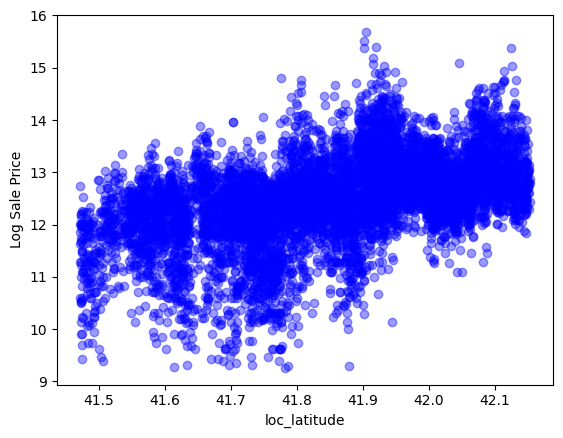

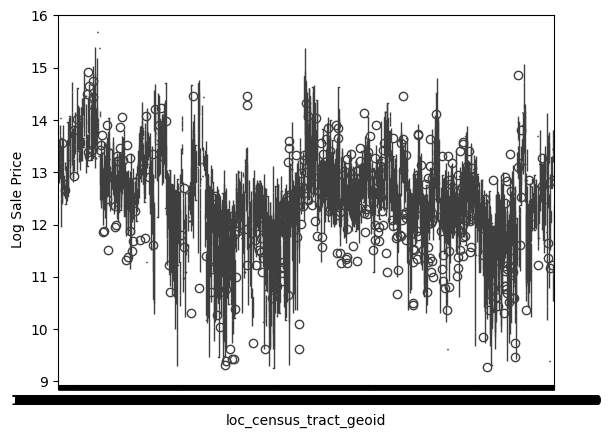

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


# ============================================================
# Minimal data prep for predictive models
# ============================================================

DATA_PATH = "data/CCAO/2025/training_data.parquet"   # change to your file path
DATE_COL = "meta_sale_date"
TARGET_COL = "meta_sale_price"

# Read yaml file
import yaml

# Open and parse the YAML file
with open("params.yaml", "r") as file:
    try:
        params = yaml.safe_load(file)
        print(params)
    except yaml.YAMLError as error:
        print(f"Error parsing YAML file: {error}")

print(params)

PREDICTOR_COLS = params["model"]["predictor"]["all"]

# [
#     # Add your final model features here, for example:
#     # "building_sqft",
#     # "land_sqft",
#     # "year_built",
#     # "property_class",
#     # "township",
# ]

CATEGORICAL_COLS = params["model"]["predictor"]["categorical"]

# [
#     # Add categorical columns from PREDICTOR_COLS here, for example:
#     # "property_class",
#     # "township",
# ]
# 

# ---------- read data ----------
if DATA_PATH.endswith(".csv"):
    df = pd.read_csv(DATA_PATH)
else:
    df = pd.read_parquet(DATA_PATH)

# Sample
sample_size = 10000
df = df.sample(sample_size)

# ---------- clean and sort ----------
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

needed_cols = [DATE_COL, TARGET_COL] + PREDICTOR_COLS
df_model = df[needed_cols].copy()

df_model = df_model[df_model[TARGET_COL].notna()]
df_model = df_model[df_model[TARGET_COL] > 0]
df_model = df_model.sort_values(DATE_COL).reset_index(drop=True)

for col in CATEGORICAL_COLS:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype("category")


# ---------- time-based train/test split ----------
cutoff = df_model[DATE_COL].quantile(0.8)

train_df = df_model[df_model[DATE_COL] <= cutoff].copy()
test_df = df_model[df_model[DATE_COL] > cutoff].copy()


# ---------- define X and y ----------
X_train = train_df[PREDICTOR_COLS].copy()
y_train = np.log(train_df[TARGET_COL].to_numpy())

X_test = test_df[PREDICTOR_COLS].copy()
y_test = np.log(test_df[TARGET_COL].to_numpy())


# ---------- preprocessing pipeline ----------
numeric_cols = [c for c in PREDICTOR_COLS if c not in CATEGORICAL_COLS]

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, CATEGORICAL_COLS),
    ],
    remainder="drop",
)



# # ---------- transformed data ready for predictive models ----------
# X_train_model = preprocess.fit_transform(X_train, y_train)
# X_test_model = preprocess.transform(X_test)

# # Convert sparse matrices if needed
# if hasattr(X_train_model, "toarray"):
#     X_train_model = X_train_model.toarray()

# if hasattr(X_test_model, "toarray"):
#     X_test_model = X_test_model.toarray()

# # To dataframes
# feature_names = preprocess.get_feature_names_out()
# X_train_model = pd.DataFrame(X_train_model, columns=feature_names, index=X_train.index)
# X_test_model = pd.DataFrame(X_test_model, columns=feature_names, index=X_test.index)

# X_train_model
# Print all features with "sf" at the end. Let's log them
for col in X_train.columns:
    if "_sf" in col:
        print(col)
        X_train[col] = np.log(X_train[col]) 
        X_test[col] = np.log(X_test[col])

from pandas.api.types import is_numeric_dtype
for i,col in enumerate(X_train.columns):
    if is_numeric_dtype(X_train[col]):
        plt.scatter(X_train[col], y_train, color="blue", alpha=0.4)
        plt.xlabel(col)
        plt.ylabel("Log Sale Price")
        plt.show()

    else:
        sns.boxplot(x=X_train[col], y=y_train)
        plt.xlabel(col)
        plt.ylabel("Log Sale Price")
        plt.show()

    if i > 30:
        break

# X_train_model, y_train, X_test_model, y_test are now ready.

In [ ]:
# # Train simple modelsºº

# from sklearn.linear_model import LinearRegression

# model = LinearRegression(fit_intercept=True)
# model.fit(X_train[numeric_cols], y_train)

# y_train_pred = np.exp(model.predict(X_train[numeric_cols]))
# y_test_pred = np.exp(model.predict(X_test[numeric_cols]))
# y_train_exp, y_test_exp = np.exp(y_train), np.exp(y_test)

# # RMSE and R2
# from sklearn.metrics import r2_score, mean_squared_error
# print(r2_score(y_true=y_train_exp, y_pred=y_train_pred))
# print(mean_squared_error(y_true=y_train_exp, y_pred=y_train_pred))
# print(r2_score(y_true=y_test_exp, y_pred=y_test_pred))
# print(mean_squared_error(y_true=y_test_exp, y_pred=y_test_pred))

In [2]:
#@title <p>Helper: Significance "stars" visualization on regression summary</p>

def summary_with_stars(result):
    def get_stars(p):
        for cutoff, stars in [
            (0.001, "***"),
            (0.01, "**"),
            (0.05, "*"),
            (0.1, "."),
        ]:
            if p < cutoff:
                return stars
        return ""

    star_map = {name: get_stars(p) for name, p in result.pvalues.items()}
    lines = []
    inside_coef_table = False
    added_legend = False

    for line in result.summary().as_text().splitlines():
        if "coef" in line and "P>|t|" in line:
            inside_coef_table = True
            line += "  Sig."
        else:
            parts = line.strip().split()
            row_name = parts[0] if parts else ""

            if row_name in star_map:
                line += f"  {star_map[row_name]}"

        lines.append(line)

        if inside_coef_table and not added_legend and line.strip().startswith("==="):
            lines.append(
                "Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1\n"
            )
            added_legend = True

    return "\n".join(lines)


import statsmodels.api as sm
import pandas as pd
import numpy as np


# Copy training data
X_train_copy = X_train.copy()


# Feature transformation
X_train_copy["loc_access_cmap_walk_total_score"] = (
    (X_train["loc_access_cmap_walk_total_score"]
     - X_train["loc_access_cmap_walk_total_score"].mean()) ** 2 / 1000
)


# Categorical: char_rooms
X_train_copy["char_rooms"] = X_train["char_rooms"].clip(upper=19)
X_train_copy["char_rooms"] = X_train_copy["char_rooms"].astype("category")


# Categorical: char_beds
X_train_copy["char_beds"] = X_train["char_beds"].clip(upper=5)
X_train_copy["char_beds"] = X_train_copy["char_beds"].astype("category")


# Categorical: airport DNL ranges
X_train_copy["prox_airport_dnl_total"] = pd.cut(
    X_train_copy["prox_airport_dnl_total"],
    bins=[-float("inf"), 51, 55, 65, float("inf")],
    labels=[
        "baseline_50_or_less",
        "low_51_to_55",
        "noticeable_55_to_65",
        "high_65_plus",
    ],
    right=False
)

X_train_copy["prox_airport_dnl_total"] = (
    X_train_copy["prox_airport_dnl_total"].astype("category")
)


# Piecewise transformation for rent feature
rent_col = "acs5_median_household_renter_occupied_gross_rent"

# Log transform first
X_train_copy[rent_col] = np.log(X_train_copy[rent_col])

# Range where you think the negative trend exists
L = 6.65
U = 7.10

x = X_train_copy[rent_col]

X_train_copy[f"{rent_col}_below_range"] = (x - L).clip(upper=0)
X_train_copy[f"{rent_col}_negative_range"] = x.clip(lower=L, upper=U) - L
X_train_copy[f"{rent_col}_above_range"] = (x - U).clip(lower=0)

piecewise_cols = [
    f"{rent_col}_below_range",
    f"{rent_col}_negative_range",
    f"{rent_col}_above_range",
]


# Columns to treat as categorical
categorical_cols = [
    "char_rooms",
    "prox_airport_dnl_total",
    "char_beds",
]


# Start with numeric columns only
# Exclude categorical columns and the original rent column,
# because we are replacing it with the piecewise version.
selected_numeric_cols = [
    col for col in numeric_cols[:60]
    if col not in categorical_cols + [rent_col]
]


# Build numeric model matrix
X_model = X_train_copy[selected_numeric_cols + piecewise_cols].copy()


# Fill missing values only for numeric predictors
X_model = X_model.fillna(X_model.mean())


# Convert categorical variables into dummy variables
cat_dummies = pd.get_dummies(
    X_train_copy[categorical_cols],
    drop_first=True,
    dtype=float
)


# Add categorical dummies to model matrix
X_model = pd.concat([X_model, cat_dummies], axis=1)


# Add intercept
X_model = sm.add_constant(X_model)


# Fit model
model1 = sm.OLS(y_train, X_model).fit()


# Print summary with stars
print(summary_with_stars(model1))

/tmp/ipykernel_809714/2086653199.py:131: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_model = X_model.fillna(X_model.mean())


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

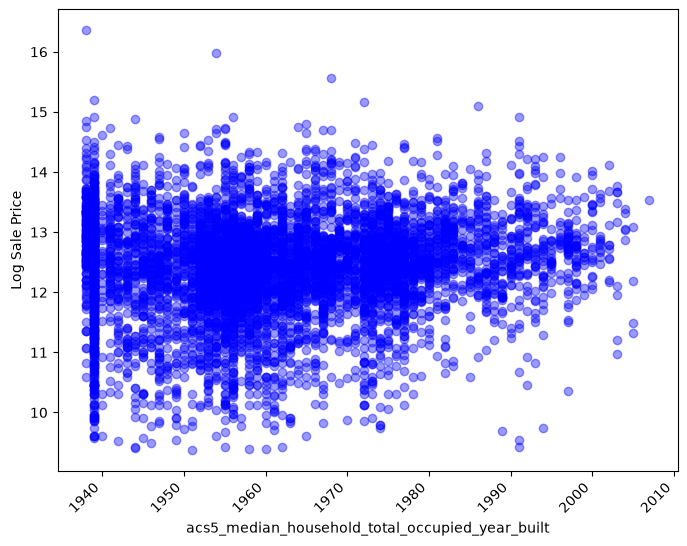

In [ ]:
col = "acs5_median_household_total_occupied_year_built"
X_train_copy = X_train.copy()

# X_train_copy[col] = np.log(X_train[col])
# X_train_copy[col] = X_train_copy[col].clip(lower=6.5)
# X_train_copy[col] = X_train[col] == X_train[col].min()
# X_train_copy[col] = X_train[col].apply(lambda x: 0 if x<=6 else 1)
# X_train_copy[col] = X_train_copy[col].astype("category")
# X_train_copy[col] = pd.cut(
#     X_train_copy[col],
#     bins=[50, 51, 55, 65, float("inf")],
#     labels=[
#         "baseline_50_or_less",
#         "low_50_to_55",
#         "noticeable_55_to_65",
#         "significant_65_plus"
#     ],
#     right=False
# )
# X_train_copy[col] = pd.cut(
#     X_train_copy[col],
#     bins=[-float("inf"), 51, 55, float("inf")],
#     labels=[
#         "baseline_50_or_less",
#         # "low_51_to_55",
#         "noticable_55_to_65",
#         "high_65",
#     ],
#     right=False
# )

plt.figure(figsize=(8,6))
plt.scatter(X_train_copy[col], y_train, color="blue", alpha=0.4)
# sns.boxplot(x=X_train_copy[col], y=y_train)
plt.xlabel(col)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Log Sale Price")
plt.show()

In [ ]:
loc_env_flood_fs_factor